In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('jj.csv')
df

,date,data
0,1960-01-01,0.71
1,1960-04-01,0.63
2,1960-07-02,0.85
3,1960-10-01,0.44
4,1961-01-01,0.61
...,...,...
79,1979-10-01,9.99
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02


In [2]:
train = df[:-4]
test = df[-4:]

test

,date,data
80,1980-01-01,16.20
81,1980-04-01,14.67
82,1980-07-02,16.02
83,1980-10-01,11.61


In [3]:
historical_mean = np.mean(train['data'])
historical_mean

np.float64(4.308499987499999)

In [4]:
test.loc[:, 'pred_mean'] = historical_mean

In [5]:
test

,date,data,pred_mean
80,1980-01-01,16.20,4.3085
81,1980-04-01,14.67,4.3085
82,1980-07-02,16.02,4.3085
83,1980-10-01,11.61,4.3085


In [6]:
#error = test['data'] - test['pred_mean']

#np.abs(error / test['data'])

In [7]:

#es el mean de los porcentajes
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

mape(test['data'],test['pred_mean'])

np.float64(70.00752579965119)

In [8]:
np.arange(0,85,8)

array([ 0,  8, 16, 24, 32, 40, 48, 56, 64, 72, 80])

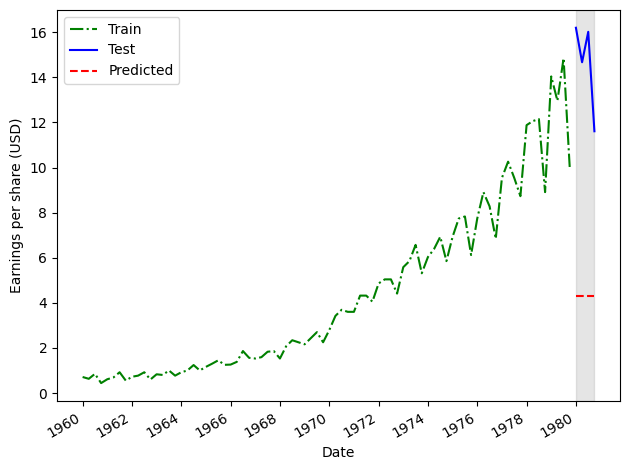

In [9]:
fig,ax = plt.subplots()

#en el mismo ax puedes plotear multiple data!
ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')
ax.plot(test['date'], test['pred_mean'], 'r--', label='Predicted')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

ax.axvspan(80,83, color='#808080', alpha=0.2)
ax.legend(loc=2)

#'son indices'
plt.xticks(np.arange(0,85,8), labels=[1960,1962,1964,1966,1968,1970,1972,1974,1976,1978,1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('prediction.png')

In [10]:
#si estuvieran hacia arriba tambien seria 70%
#son valores absolutos
#70% below

trend
last year mean

forcast it for each quarter

In [11]:
train.iloc[-4:]

,date,data
76,1979-01-01,14.04
77,1979-04-02,12.96
78,1979-07-02,14.85
79,1979-10-01,9.99


In [12]:
last_year_mean = np.mean(train.data[-4:])
last_year_mean

np.float64(12.96)

In [13]:
test.loc[:,'pred_last_yr_mean'] = last_year_mean

In [14]:
test

,date,data,pred_mean,pred_last_yr_mean
80,1980-01-01,16.20,4.3085,12.96
81,1980-04-01,14.67,4.3085,12.96
82,1980-07-02,16.02,4.3085,12.96
83,1980-10-01,11.61,4.3085,12.96


In [15]:
mape(
    test['data'],
    test['pred_last_yr_mean']
)

np.float64(15.5963680725103)

autocorrelation

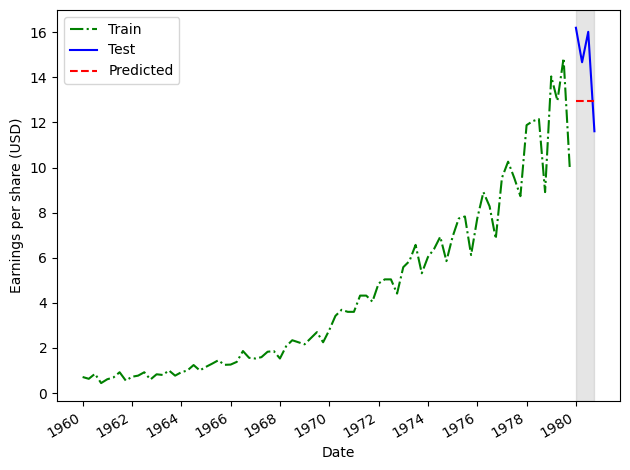

In [16]:
fig,ax = plt.subplots()

#en el mismo ax puedes plotear multiple data!
ax.plot(train['date'], train['data'], 'g-.', label='Train')
ax.plot(test['date'], test['data'], 'b-', label='Test')

ax.plot(test['date'], test['pred_last_yr_mean'], 'r--', label='Predicted')

ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')

ax.axvspan(80,83, color='#808080', alpha=0.2)
ax.legend(loc=2)

#'son indices'
plt.xticks(np.arange(0,85,8), labels=[1960,1962,1964,1966,1968,1970,1972,1974,1976,1978,1980])

fig.autofmt_xdate()
plt.tight_layout()

plt.savefig('prediction_2.png')

other baseline